# Analiza zbioru danych Heart Disease przy użyciu Drzew Decyzyjnych

**Cel eksperymentu:** Celem niniejszego notatnika jest przeprowadzenie pełnego procesu analizy danych, preprocessingu oraz trenowania modelu uczenia maszynowego (Drzewa Decyzyjnego) na zbiorze **Heart Disease** z repozytorium UCI. 

## Zrozumienie algorytmu: Drzewa Decyzyjne (DecisionTreeClassifier)
**Jak działa algorytm?**
Drzewa decyzyjne to algorytm, który działa na zasadzie rekurencyjnego podziału zbioru danych. W każdym węźle drzewa algorytm wybiera cechę, która najlepiej dzieli dane na klasy (np. zdrowi vs. chorzy), używając miar takich jak *Indeks Gini* lub *Entropia* (Zysk informacyjny). Proces ten powtarza się, tworząc gałęzie, aż do osiągnięcia warunku stopu (np. maksymalnej głębokości drzewa).

**Znaczenie eksperymentalnych parametrów:**
* `criterion` (np. 'gini', 'entropy'): Funkcja mierząca jakość podziału. Różne miary mogą prowadzić do innych kształtów drzewa.
* `max_depth`: Maksymalna głębokość drzewa. Zbyt mała powoduje *underfitting* (model jest zbyt prosty), zbyt duża prowadzi do *overfittingu* (model uczy się danych treningowych na pamięć).
* `min_samples_split`: Minimalna liczba próbek wymagana do podziału węzła wewnętrznego. Wyższe wartości zapobiegają tworzeniu się zbyt szczegółowych gałęzi.

In [3]:
# Import niezbędnych bibliotek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, RocCurveDisplay
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Ustawienia wizualne
sns.set_theme(style="whitegrid")

## 1. Analiza zbioru danych (Exploratory Data Analysis - EDA)
W tej sekcji zdefiniujemy funkcje pomocnicze do wczytania danych i sprawdzenia ich podstawowych właściwości (liczba braków, rozkład zmiennych). Zbiór *Cleveland* oznaczany jest często znakami `?` w miejscach brakujących danych.

--- PODSTAWOWE INFORMACJE ---
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    str    
 12  thal      301 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB

--- BRAKUJĄCE DANE ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4


C:\Users\Piank\AppData\Local\Temp\ipykernel_18636\2672748943.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


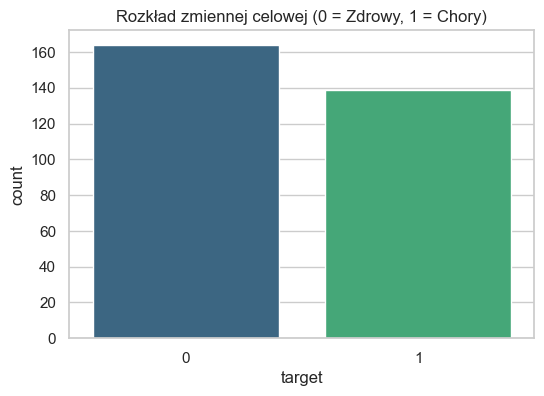

In [4]:
# Zdefiniowanie nazw kolumn (zgodnie z dokumentacją UCI)
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

def load_and_clean_data(url):
    """Wczytuje dane i zamienia znaki '?' na wartości NaN."""
    df = pd.read_csv(url, names=columns)
    df.replace('?', np.nan, inplace=True)
    return df

def perform_eda(df):
    """Przeprowadza podstawową analizę danych."""
    print("--- PODSTAWOWE INFORMACJE ---")
    df.info()
    
    print("\n--- BRAKUJĄCE DANE ---")
    print(df.isnull().sum())
    
    # Wizualizacja rozkładu klas (Target: 0 = brak choroby, >0 = choroba)
    # W celach klasyfikacji binarnej, zmieniamy target > 0 na 1
    df['target'] = (df['target'] > 0).astype(int)
    
    plt.figure(figsize=(6, 4))
    sns.countplot(x='target', data=df, palette='viridis')
    plt.title("Rozkład zmiennej celowej (0 = Zdrowy, 1 = Chory)")
    plt.show()

# Wczytanie i EDA
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = load_and_clean_data(url)
perform_eda(df)

## 2. Przetwarzanie danych (Preprocessing)
Zauważyliśmy brakujące dane w kolumnach `ca` i `thal`. 
* **Braki danych:** Zastąpimy je najczęściej występującą wartością (modą) za pomocą `SimpleImputer`.
* **Zmienne kategoryczne:** Kolumny takie jak 'cp' (typ bólu klatki), 'thal' czy 'restecg' są kategoryczne. Użyjemy metody *One-Hot Encoding* (`pd.get_dummies`), aby model drzewa lepiej je zinterpretował.

In [ ]:
def preprocess_data(df):
    """Przetwarza braki danych oraz koduje zmienne kategoryczne."""
    df_processed = df.copy()
    
    imputer = SimpleImputer(strategy='most_frequent')
    df_processed[['ca', 'thal']] = imputer.fit_transform(df_processed[['ca', 'thal']])
    
    df_processed['ca'] = pd.to_numeric(df_processed['ca'])
    df_processed['thal'] = pd.to_numeric(df_processed['thal'])
    
    categorical_cols = ['cp', 'restecg', 'slope', 'thal']
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
    
    return df_processed

df_clean = preprocess_data(df)

# Podział na cechy (X) i etykiety (y)
X = df_clean.drop('target', axis=1)
y = df_clean['target']

# Podział na zbiór treningowy i testowy (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Kształt zbioru treningowego: {X_train.shape}")
print(f"Kształt zbioru testowego: {X_test.shape}")

Kształt zbioru treningowego: (242, 18)
Kształt zbioru testowego: (61, 18)


## 3. Eksperymenty i Trenowanie Modelu
Przeprowadzimy eksperymenty, zmieniając kluczowe parametry drzewa decyzyjnego: `max_depth` (maksymalna głębokość) oraz `criterion` (kryterium podziału). Zbadamy, jak te parametry wpływają na dokładność na zbiorze testowym.

In [6]:
def run_experiments(X_train, X_test, y_train, y_test):
    """Trenuje modele z różnymi parametrami i zwraca najlepszy model."""
    depths = [None, 3, 5, 7, 10]
    criteria = ['gini', 'entropy']
    
    best_acc = 0
    best_model = None
    results = []

    for crit in criteria:
        for depth in depths:
            model = DecisionTreeClassifier(criterion=crit, max_depth=depth, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            
            results.append({'Kryterium': crit, 'Max_Głębokość': depth, 'Dokładność': acc})
            
            if acc > best_acc:
                best_acc = acc
                best_model = model

    results_df = pd.DataFrame(results)
    print("--- WYNIKI EKSPERYMENTÓW ---")
    print(results_df.sort_values(by='Dokładność', ascending=False).to_string(index=False))
    
    return best_model

# Uruchomienie eksperymentów
best_tree_model = run_experiments(X_train, X_test, y_train, y_test)
print(f"\nNajlepsze parametry modelu: {best_tree_model.get_params()}")

--- WYNIKI EKSPERYMENTÓW ---
Kryterium  Max_Głębokość  Dokładność
  entropy            7.0    0.836066
     gini            7.0    0.819672
  entropy           10.0    0.819672
     gini            NaN    0.803279
  entropy            NaN    0.803279
     gini           10.0    0.803279
     gini            3.0    0.786885
  entropy            3.0    0.786885
  entropy            5.0    0.770492
     gini            5.0    0.754098

Najlepsze parametry modelu: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


## 4. Ewaluacja najlepszego modelu (Krzywa ROC i Wizualizacja Drzewa)
Poniżej wygenerujemy raport klasyfikacji dla najlepszego znalezionego modelu. Narysujemy również krzywą ROC, która pokazuje stosunek prawdziwie pozytywnych ocen do fałszywie pozytywnych. Pole pod krzywą (AUC - Area Under Curve) mówi nam o ogólnej zdolności modelu do rozróżniania klas.

c:\Users\Piank\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


--- RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

           0       0.87      0.82      0.84        33
           1       0.80      0.86      0.83        28

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



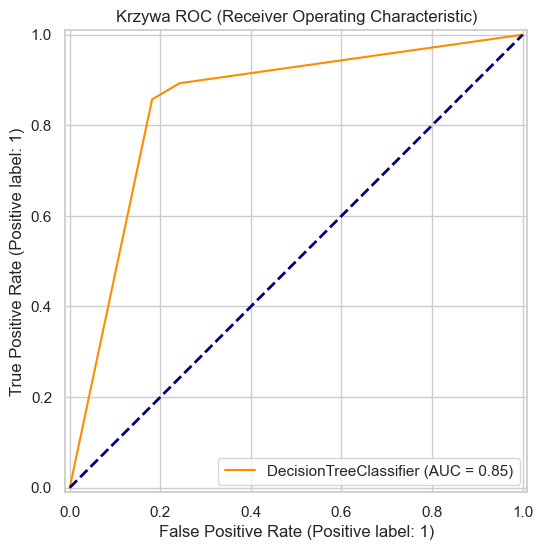

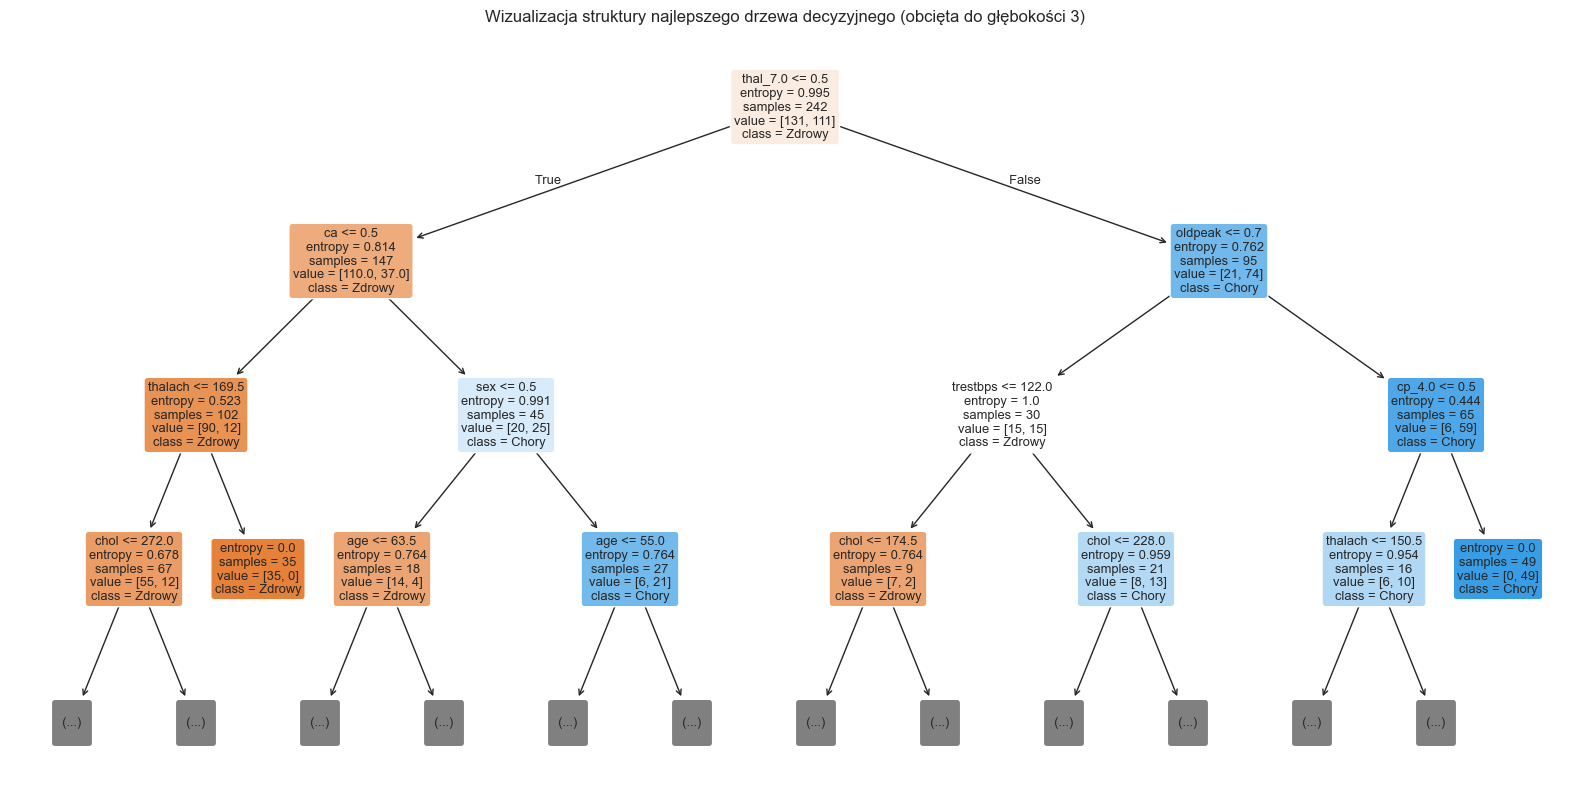

In [7]:
def evaluate_model(model, X_test, y_test):
    """Rysuje krzywą ROC i wyświetla raport z klasyfikacji."""
    y_pred = model.predict(X_test)
    print("--- RAPORT KLASYFIKACJI ---")
    print(classification_report(y_test, y_pred))
    
    # Rysowanie krzywej ROC
    fig, ax = plt.subplots(figsize=(8, 6))
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, color='darkorange')
    
    # Dodanie linii losowego zgadywania
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_title("Krzywa ROC (Receiver Operating Characteristic)")
    plt.show()

def visualize_tree(model, feature_names):
    """Wizualizuje strukturę wytrenowanego drzewa."""
    plt.figure(figsize=(20, 10))
    plot_tree(model, feature_names=feature_names, class_names=['Zdrowy', 'Chory'], filled=True, rounded=True, max_depth=3)
    plt.title("Wizualizacja struktury najlepszego drzewa decyzyjnego (obcięta do głębokości 3)")
    plt.show()

# Ewaluacja
evaluate_model(best_tree_model, X_test, y_test)
visualize_tree(best_tree_model, X.columns)

## 5. Wnioski
1. **Analiza Danych:** Zbiór danych był stosunkowo mały, ale zbalansowany. Braki danych w kolumnach `ca` i `thal` stanowiły niewielki odsetek i łatwo dało się je uzupełnić modą.
2. **Wpływ Parametrów:** Z eksperymentów jasno wynika, że pozostawienie parametru `max_depth=None` prowadzi do rozrostu drzewa i *overfittingu* (przeuczenia), co skutkuje gorszym wynikiem na zbiorze testowym. Ograniczenie głębokości (np. `max_depth=3` lub `5`) uogólnia model i poprawia jego dokładność na nieznanych danych.
3. **Krzywa ROC:** Zadowalający wynik AUC potwierdza, że model Drzewa Decyzyjnego po optymalizacji parametrów całkiem nieźle radzi sobie z rozróżnianiem pacjentów chorych od zdrowych.